### Tech Assessment - Data Analyst
Made by: Divya Natekar

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.inspection import permutation_importance

In [3]:
base_dir = "/content/drive/MyDrive"
csv_path = None

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file.lower() == "globalweatherrepository.csv":
            csv_path = os.path.join(root, file)
            break
    if csv_path:
        break

csv_path

'/content/drive/MyDrive/GlobalWeatherRepository.csv'

In [4]:
df = pd.read_csv(csv_path)
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [5]:
df.shape

(142678, 41)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142678 entries, 0 to 142677
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       142678 non-null  object 
 1   location_name                 142678 non-null  object 
 2   latitude                      142678 non-null  float64
 3   longitude                     142678 non-null  float64
 4   timezone                      142678 non-null  object 
 5   last_updated_epoch            142678 non-null  int64  
 6   last_updated                  142678 non-null  object 
 7   temperature_celsius           142678 non-null  float64
 8   temperature_fahrenheit        142678 non-null  float64
 9   condition_text                142678 non-null  object 
 10  wind_mph                      142678 non-null  float64
 11  wind_kph                      142678 non-null  float64
 12  wind_degree                   142678 non-nul

In [7]:
df["last_updated"] = pd.to_datetime(df["last_updated"], errors="coerce")
df["date"] = df["last_updated"].dt.date
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["last_updated"].dt.year
df["month"] = df["last_updated"].dt.month
df["day"] = df["last_updated"].dt.day
df["dayofyear"] = df["last_updated"].dt.dayofyear
df["weekday"] = df["last_updated"].dt.weekday
df = df.drop_duplicates()
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,moonrise,moonset,moon_phase,moon_illumination,date,year,month,day,dayofyear,weekday
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,...,12:12 PM,01:11 AM,Waxing Gibbous,55,2024-05-16,2024,5,16,137,3
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,...,12:58 PM,02:14 AM,Waxing Gibbous,55,2024-05-16,2024,5,16,137,3
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,73.4,Sunny,...,01:15 PM,02:14 AM,Waxing Gibbous,55,2024-05-16,2024,5,16,137,3
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,43.3,Light drizzle,...,02:12 PM,03:31 AM,Waxing Gibbous,55,2024-05-16,2024,5,16,137,3
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,...,01:17 PM,12:38 AM,Waxing Gibbous,55,2024-05-16,2024,5,16,137,3


In [8]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

,0


In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

for col in numeric_cols:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

df.isna().sum().sum()

np.int64(0)

In [10]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
latitude,142678.0,19.218604,-41.3,4.0503,17.25,40.4,64.15,24.412143
longitude,142678.0,21.933384,-175.2,-6.8361,23.2361,49.8822,179.22,65.782277
last_updated_epoch,142678.0,1747602486.144325,1715849100.0,1731746700.0,1747645200.0,1763451000.0,1779345000.0,18328643.178551
last_updated,142678,2025-05-18 23:17:28.961297920,2024-05-16 01:45:00,2024-11-16 15:45:00,2025-05-19 03:30:00,2025-11-18 03:30:00,2026-05-21 19:30:00,NaN
temperature_celsius,142678.0,21.240256,-29.8,15.5,23.7,28.0,79.3,9.633318
temperature_fahrenheit,142678.0,70.234241,-21.6,59.9,74.7,82.3,174.7,17.339852
wind_mph,142678.0,7.985468,2.2,3.8,6.7,11.0,1841.2,7.121121
wind_kph,142678.0,12.855084,3.6,6.1,10.8,17.6,2963.2,11.45702
wind_degree,142678.0,168.968418,1.0,80.0,161.0,256.0,360.0,103.666635
pressure_mb,142678.0,1014.031497,947.0,1010.0,1013.0,1018.0,3006.0,10.181365


In [11]:
daily = df.groupby("date").agg(
    avg_temperature_celsius=("temperature_celsius", "mean"),
    avg_feels_like_celsius=("feels_like_celsius", "mean"),
    avg_humidity=("humidity", "mean"),
    avg_precip_mm=("precip_mm", "mean"),
    avg_pressure_mb=("pressure_mb", "mean"),
    avg_pm25=("air_quality_PM2.5", "mean"),
    avg_pm10=("air_quality_PM10", "mean"),
    avg_uv_index=("uv_index", "mean")
).reset_index()

daily = daily.sort_values("date")
daily.head()

,date,avg_temperature_celsius,avg_feels_like_celsius,avg_humidity,avg_precip_mm,avg_pressure_mb,avg_pm25,avg_pm10,avg_uv_index
0,2024-05-16,23.767196,25.369841,61.679894,0.113175,1013.412698,18.718254,33.194974,4.986772
1,2024-05-17,24.451648,26.378022,59.763736,0.147088,1013.269231,17.333516,32.553846,4.021978
2,2024-05-18,25.355610,27.599512,58.585366,0.127854,1012.853659,17.375122,33.416098,4.960976
3,2024-05-19,25.270103,27.296907,60.360825,0.162938,1012.041237,14.461340,30.090722,5.190722
4,2024-05-20,25.430769,27.442564,59.610256,0.170513,1012.441026,19.024103,36.299487,5.164103


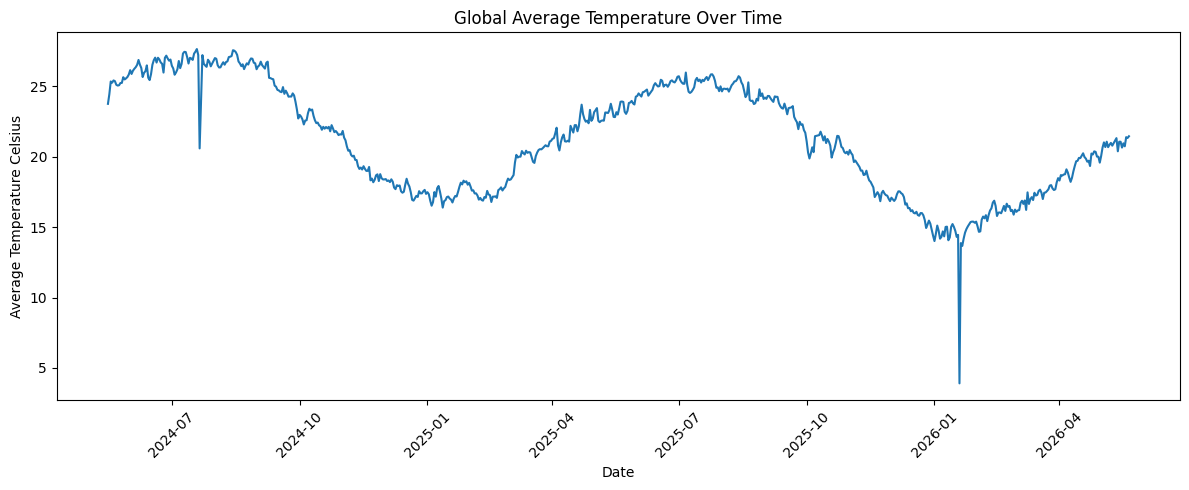

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(daily["date"], daily["avg_temperature_celsius"])
plt.title("Global Average Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Average Temperature Celsius")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

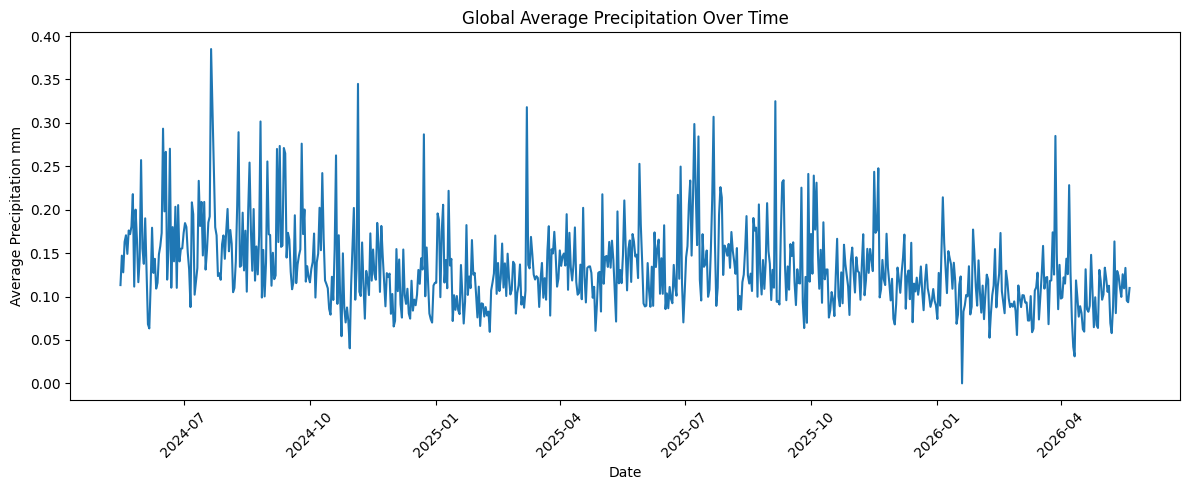

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(daily["date"], daily["avg_precip_mm"])
plt.title("Global Average Precipitation Over Time")
plt.xlabel("Date")
plt.ylabel("Average Precipitation mm")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

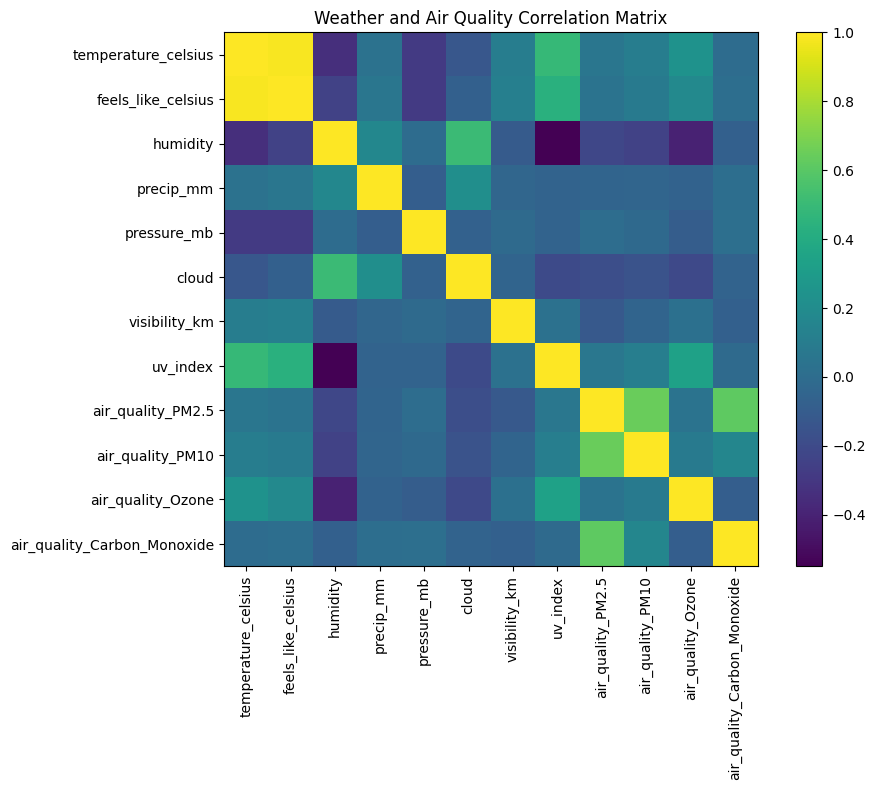

In [14]:
corr_cols = [
    "temperature_celsius",
    "feels_like_celsius",
    "humidity",
    "precip_mm",
    "pressure_mb",
    "cloud",
    "visibility_km",
    "uv_index",
    "air_quality_PM2.5",
    "air_quality_PM10",
    "air_quality_Ozone",
    "air_quality_Carbon_Monoxide"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Weather and Air Quality Correlation Matrix")
plt.tight_layout()
plt.show()

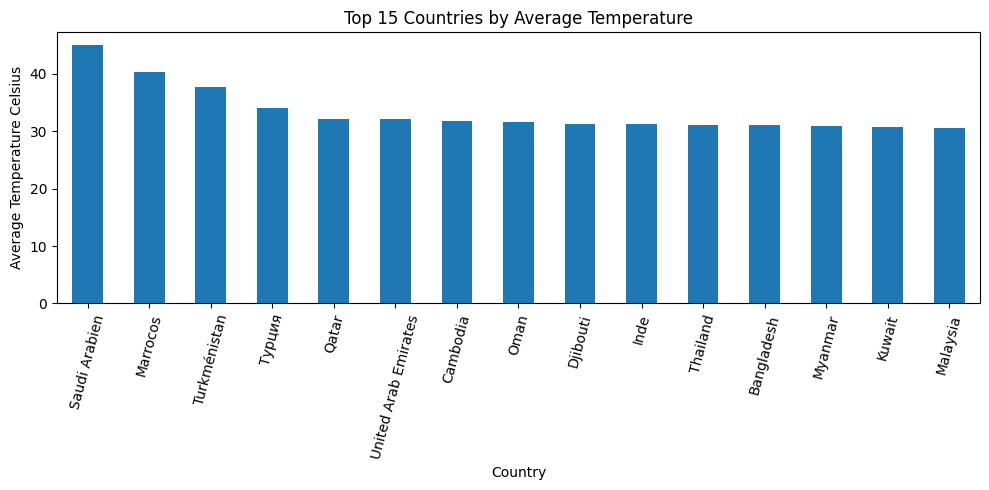

In [15]:
country_temp = df.groupby("country")["temperature_celsius"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
country_temp.plot(kind="bar")
plt.title("Top 15 Countries by Average Temperature")
plt.xlabel("Country")
plt.ylabel("Average Temperature Celsius")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

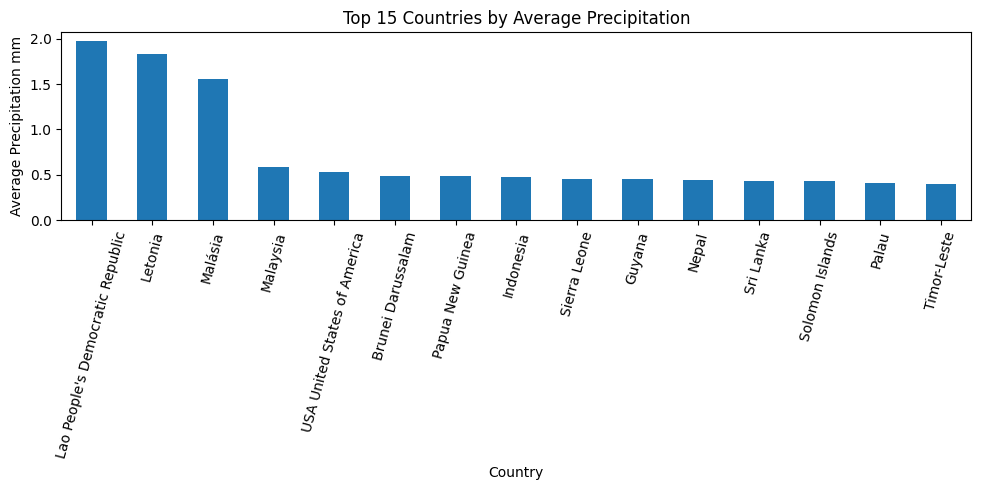

In [16]:
country_precip = df.groupby("country")["precip_mm"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
country_precip.plot(kind="bar")
plt.title("Top 15 Countries by Average Precipitation")
plt.xlabel("Country")
plt.ylabel("Average Precipitation mm")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [17]:
anomaly_features = [
    "temperature_celsius",
    "humidity",
    "precip_mm",
    "pressure_mb",
    "wind_kph",
    "air_quality_PM2.5",
    "air_quality_PM10"
]

iso = IsolationForest(contamination=0.03, random_state=42)
df["anomaly"] = iso.fit_predict(df[anomaly_features])
df["anomaly_label"] = np.where(df["anomaly"] == -1, "Anomaly", "Normal")

df["anomaly_label"].value_counts()

,count
anomaly_label,
Normal,138397
Anomaly,4281


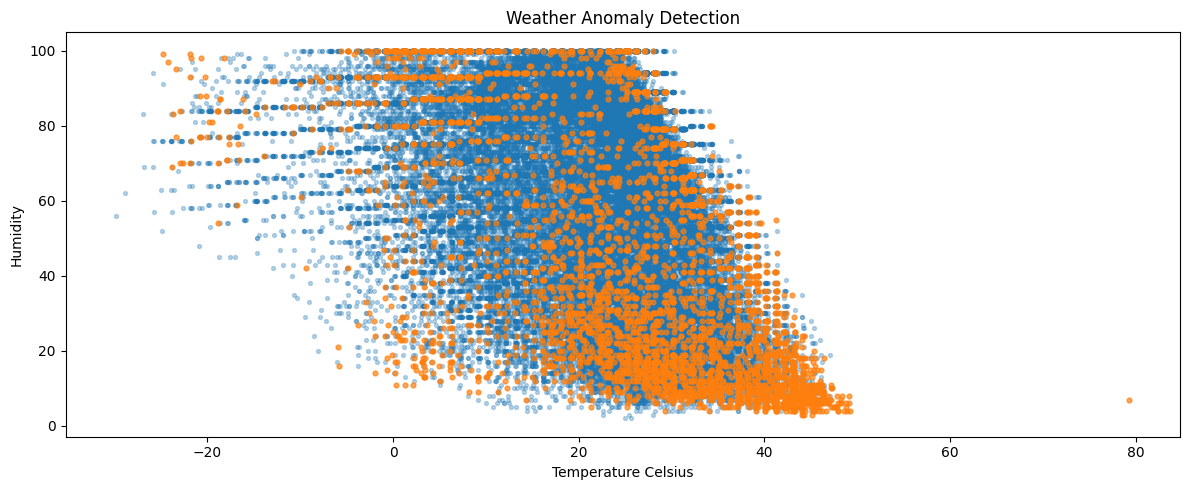

In [18]:
plt.figure(figsize=(12, 5))
normal = df[df["anomaly_label"] == "Normal"]
anomalies = df[df["anomaly_label"] == "Anomaly"]
plt.scatter(normal["temperature_celsius"], normal["humidity"], s=8, alpha=0.3)
plt.scatter(anomalies["temperature_celsius"], anomalies["humidity"], s=12, alpha=0.7)
plt.title("Weather Anomaly Detection")
plt.xlabel("Temperature Celsius")
plt.ylabel("Humidity")
plt.tight_layout()
plt.show()

In [19]:
model_df = df.copy()
model_df = model_df.sort_values("last_updated")

target = "temperature_celsius"

drop_cols = [
    target,
    "temperature_fahrenheit",
    "feels_like_fahrenheit",
    "last_updated",
    "last_updated_epoch",
    "date",
    "anomaly",
    "anomaly_label"
]

features = [col for col in model_df.columns if col not in drop_cols]

X = model_df[features]
y = model_df[target]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", max_categories=30))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

trained_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append([name, mae, rmse, r2])
    trained_models[name] = pipe

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"]).sort_values("RMSE")
results_df

,Model,MAE,RMSE,R2
2,Random Forest,0.177949,0.450415,0.998255
3,Gradient Boosting,0.331727,0.559389,0.997308
0,Linear Regression,0.940943,1.264740,0.986238
1,Ridge Regression,0.941820,1.278094,0.985945


In [20]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_model_name

'Random Forest'

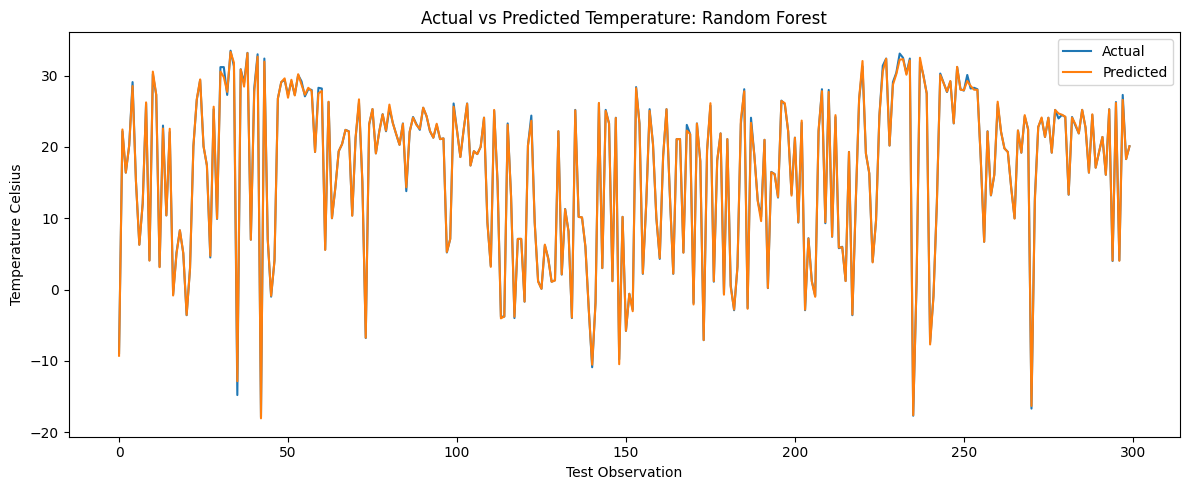

In [21]:
best_preds = best_model.predict(X_test)

plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:300], label="Actual")
plt.plot(best_preds[:300], label="Predicted")
plt.title(f"Actual vs Predicted Temperature: {best_model_name}")
plt.xlabel("Test Observation")
plt.ylabel("Temperature Celsius")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
ensemble_preds = np.mean([
    trained_models["Random Forest"].predict(X_test),
    trained_models["Gradient Boosting"].predict(X_test),
    trained_models["Ridge Regression"].predict(X_test)
], axis=0)

ensemble_mae = mean_absolute_error(y_test, ensemble_preds)
ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_preds))
ensemble_r2 = r2_score(y_test, ensemble_preds)

ensemble_row = pd.DataFrame([["Ensemble Model", ensemble_mae, ensemble_rmse, ensemble_r2]], columns=["Model", "MAE", "RMSE", "R2"])
final_results = pd.concat([results_df, ensemble_row], ignore_index=True).sort_values("RMSE")
final_results

,Model,MAE,RMSE,R2
0,Random Forest,0.177949,0.450415,0.998255
1,Gradient Boosting,0.331727,0.559389,0.997308
4,Ensemble Model,0.418392,0.629441,0.996591
2,Linear Regression,0.940943,1.264740,0.986238
3,Ridge Regression,0.941820,1.278094,0.985945


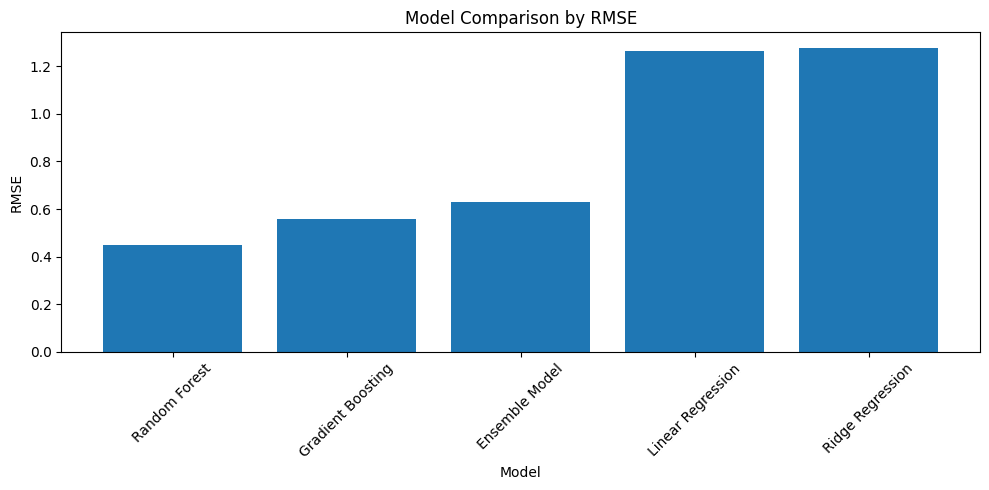

In [23]:
plt.figure(figsize=(10, 5))
plt.bar(final_results["Model"], final_results["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
sample_size = min(4000, len(X_test))
X_sample = X_test.sample(sample_size, random_state=42)
y_sample = y_test.loc[X_sample.index]

perm = permutation_importance(best_model, X_sample, y_sample, n_repeats=5, random_state=42, scoring="neg_root_mean_squared_error")

importance_df = pd.DataFrame({
    "feature": features,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False).head(20)

importance_df

,feature,importance
16,feels_like_celsius,14.647116
14,humidity,0.873067
6,wind_mph,0.250792
7,wind_kph,0.232291
2,latitude,0.018167
20,gust_mph,0.017896
19,uv_index,0.017839
21,gust_kph,0.017786
3,longitude,0.017272
11,pressure_in,0.010957


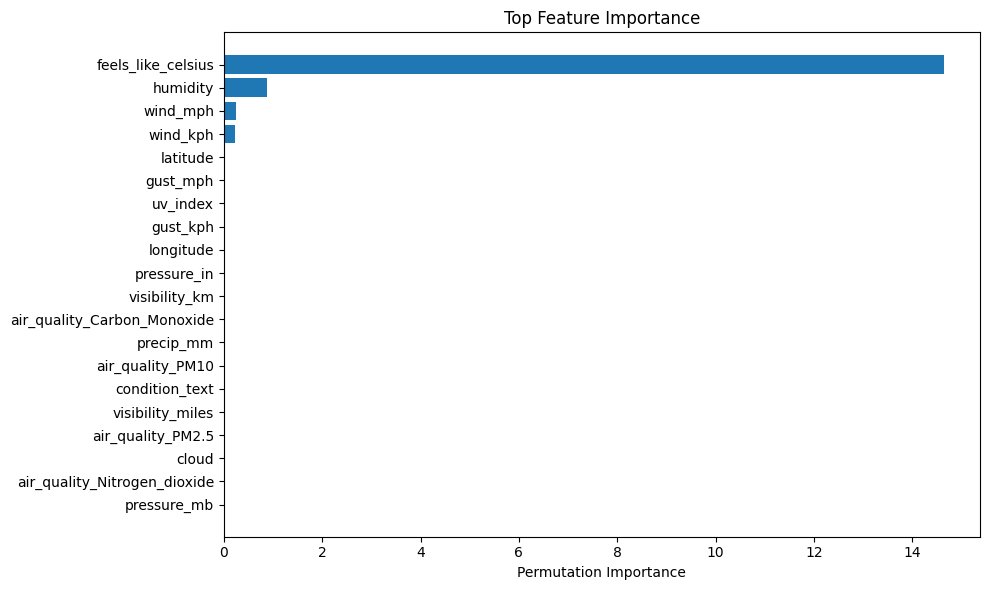

In [25]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
plt.title("Top Feature Importance")
plt.xlabel("Permutation Importance")
plt.tight_layout()
plt.show()

In [26]:
air_quality_corr = df[
    [
        "temperature_celsius",
        "humidity",
        "precip_mm",
        "wind_kph",
        "pressure_mb",
        "air_quality_PM2.5",
        "air_quality_PM10",
        "air_quality_Ozone",
        "air_quality_Carbon_Monoxide",
        "air_quality_Nitrogen_dioxide",
        "air_quality_Sulphur_dioxide"
    ]
].corr()

air_quality_corr

,temperature_celsius,humidity,precip_mm,wind_kph,pressure_mb,air_quality_PM2.5,air_quality_PM10,air_quality_Ozone,air_quality_Carbon_Monoxide,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide
temperature_celsius,1.000000,-0.339133,0.034431,0.091987,-0.288090,0.061546,0.110277,0.243477,0.001612,-0.134257,-0.032190
humidity,-0.339133,1.000000,0.170715,-0.079144,-0.001773,-0.218025,-0.240314,-0.399196,-0.076109,-0.107048,-0.112957
precip_mm,0.034431,0.170715,1.000000,0.008371,-0.086591,-0.052076,-0.043135,-0.061384,0.010455,-0.029450,-0.022274
wind_kph,0.091987,-0.079144,0.008371,1.000000,-0.089535,-0.038245,0.057906,0.122650,-0.099846,-0.120144,-0.047609
pressure_mb,-0.288090,-0.001773,-0.086591,-0.089535,1.000000,0.007424,-0.019940,-0.093922,0.017032,0.062374,0.028920
air_quality_PM2.5,0.061546,-0.218025,-0.052076,-0.038245,0.007424,1.000000,0.649061,0.041562,0.612924,0.524500,0.329280
air_quality_PM10,0.110277,-0.240314,-0.043135,0.057906,-0.019940,0.649061,1.000000,0.087981,0.163512,0.185239,0.140430
air_quality_Ozone,0.243477,-0.399196,-0.061384,0.122650,-0.093922,0.041562,0.087981,1.000000,-0.086131,-0.235711,-0.037952
air_quality_Carbon_Monoxide,0.001612,-0.076109,0.010455,-0.099846,0.017032,0.612924,0.163512,-0.086131,1.000000,0.606309,0.338910
air_quality_Nitrogen_dioxide,-0.134257,-0.107048,-0.029450,-0.120144,0.062374,0.524500,0.185239,-0.235711,0.606309,1.000000,0.450901


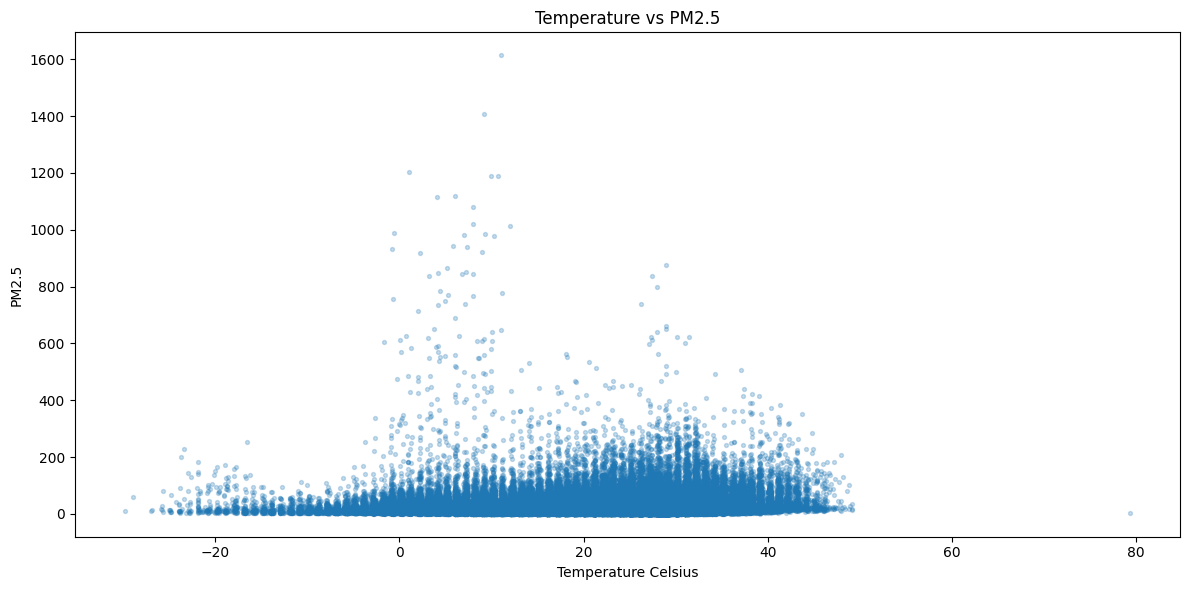

In [27]:
plt.figure(figsize=(12, 6))
plt.scatter(df["temperature_celsius"], df["air_quality_PM2.5"], alpha=0.25, s=8)
plt.title("Temperature vs PM2.5")
plt.xlabel("Temperature Celsius")
plt.ylabel("PM2.5")
plt.tight_layout()
plt.show()

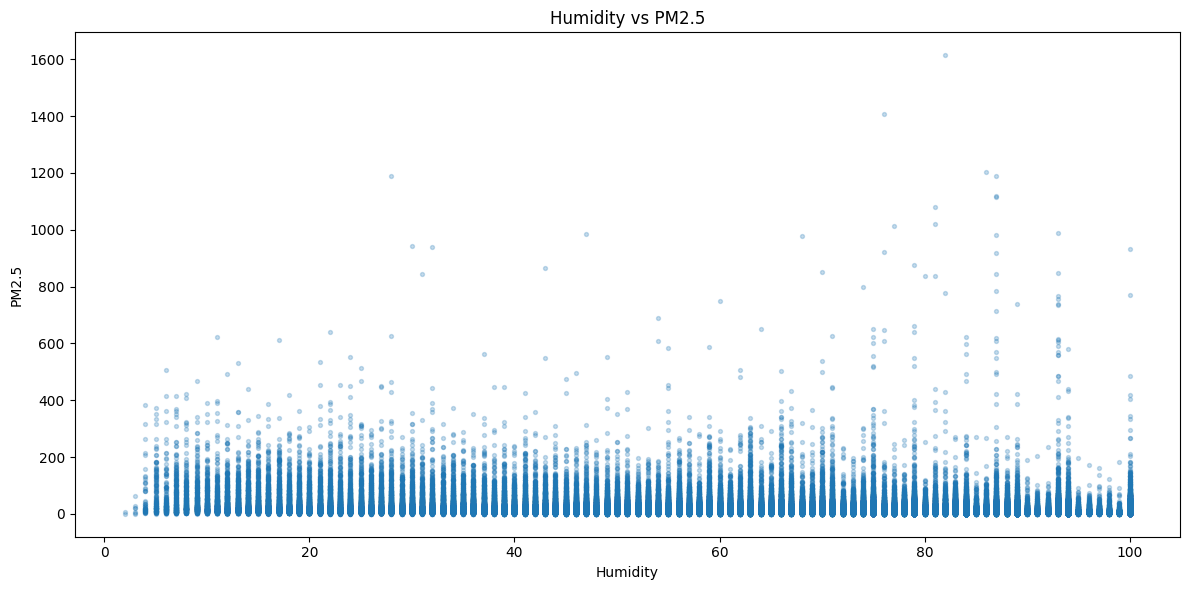

In [28]:
plt.figure(figsize=(12, 6))
plt.scatter(df["humidity"], df["air_quality_PM2.5"], alpha=0.25, s=8)
plt.title("Humidity vs PM2.5")
plt.xlabel("Humidity")
plt.ylabel("PM2.5")
plt.tight_layout()
plt.show()

In [29]:
spatial_df = df.groupby(["country", "location_name", "latitude", "longitude"]).agg(
    avg_temperature_celsius=("temperature_celsius", "mean"),
    avg_precip_mm=("precip_mm", "mean"),
    avg_humidity=("humidity", "mean"),
    avg_pm25=("air_quality_PM2.5", "mean")
).reset_index()

spatial_df.head()

,country,location_name,latitude,longitude,avg_temperature_celsius,avg_precip_mm,avg_humidity,avg_pm25
0,Afghanistan,Kabul,34.5167,69.1833,16.822521,0.035916,28.551261,20.491059
1,Afghanistan,Kabul,34.5200,69.1800,27.884173,0.040432,21.482014,11.458381
2,Albania,Tirana,41.3275,19.8189,16.368297,0.136425,61.134907,16.122260
3,Albania,Tirana,41.3300,19.8200,31.071223,0.159424,42.841727,9.582590
4,Algeria,Algiers,36.7600,3.0500,29.053623,0.004058,50.347826,13.106812


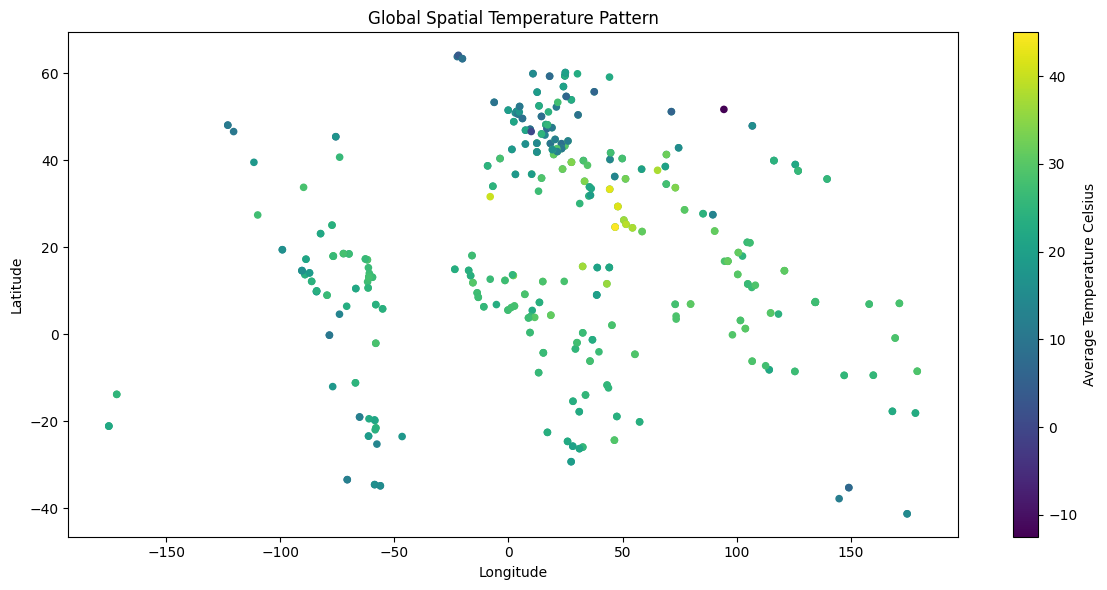

In [30]:
plt.figure(figsize=(12, 6))
plt.scatter(spatial_df["longitude"], spatial_df["latitude"], c=spatial_df["avg_temperature_celsius"], s=20)
plt.colorbar(label="Average Temperature Celsius")
plt.title("Global Spatial Temperature Pattern")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

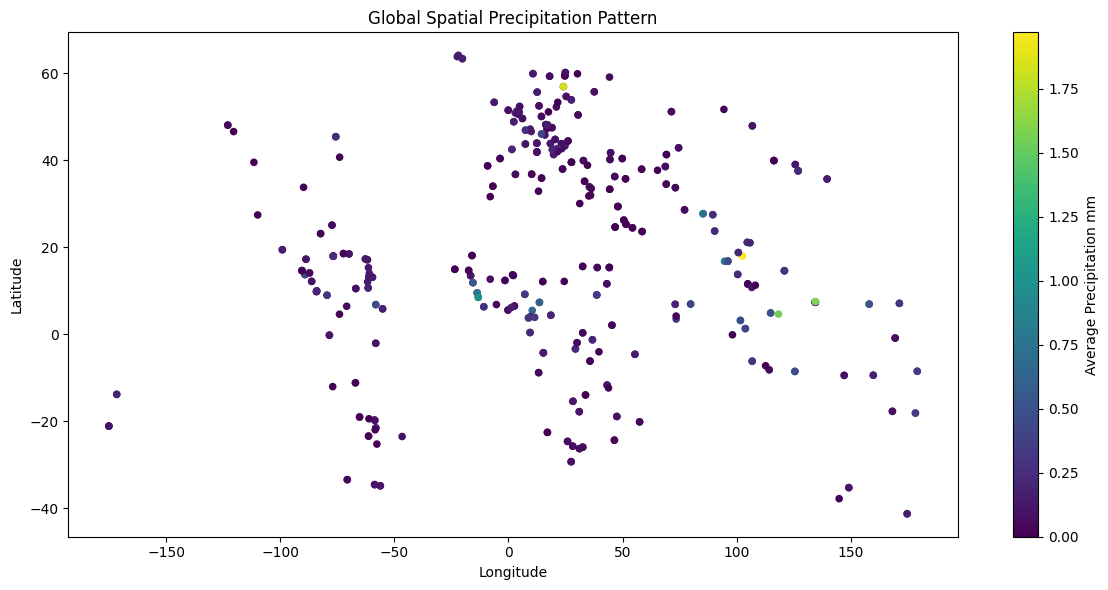

In [31]:
plt.figure(figsize=(12, 6))
plt.scatter(spatial_df["longitude"], spatial_df["latitude"], c=spatial_df["avg_precip_mm"], s=20)
plt.colorbar(label="Average Precipitation mm")
plt.title("Global Spatial Precipitation Pattern")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [32]:
country_summary = df.groupby("country").agg(
    avg_temperature_celsius=("temperature_celsius", "mean"),
    avg_precip_mm=("precip_mm", "mean"),
    avg_humidity=("humidity", "mean"),
    avg_pm25=("air_quality_PM2.5", "mean"),
    record_count=("country", "count")
).reset_index().sort_values("avg_temperature_celsius", ascending=False)

country_summary.head(20)

,country,avg_temperature_celsius,avg_precip_mm,avg_humidity,avg_pm25,record_count
158,Saudi Arabien,45.000000,0.000000,7.000000,22.300000,1
114,Marrocos,40.300000,0.000000,14.000000,8.200000,1
189,Turkménistan,37.800000,0.000000,11.000000,6.700000,1
208,Турция,34.000000,0.000000,44.000000,11.300000,1
147,Qatar,32.123256,0.000971,41.262654,56.636990,731
194,United Arab Emirates,32.122101,0.000382,44.028649,56.907306,733
29,Cambodia,31.869399,0.141448,60.528689,28.420663,732
136,Oman,31.566166,0.004256,51.005457,35.682236,733
48,Djibouti,31.292339,0.024856,56.047880,28.335547,731
77,Inde,31.200000,0.000000,71.000000,34.600000,1


In [33]:
output_dir = "/content/drive/MyDrive/weather_trend_forecasting_outputs"
os.makedirs(output_dir, exist_ok=True)

final_results.to_csv(f"{output_dir}/model_comparison.csv", index=False)
importance_df.to_csv(f"{output_dir}/feature_importance.csv", index=False)
country_summary.to_csv(f"{output_dir}/country_weather_summary.csv", index=False)
spatial_df.to_csv(f"{output_dir}/spatial_weather_summary.csv", index=False)

output_dir

'/content/drive/MyDrive/weather_trend_forecasting_outputs'

In [34]:
pm_accelerator_description = "Product Manager Accelerator is designed to support product management professionals through every stage of their careers, helping aspiring and experienced PMs build skills, prepare for interviews, and transition into product roles."

insights = f"""
# Global Weather Trend Forecasting and Climate Pattern Analysis

## PM Accelerator Mission
{pm_accelerator_description}

## Project Objective
This project analyzes the Global Weather Repository dataset to identify weather trends, detect anomalies, compare forecasting models, and study relationships between weather, geography, and air quality.

## Dataset
The dataset contains daily weather observations for cities around the world with temperature, precipitation, humidity, wind, pressure, visibility, UV index, air quality, astronomy, and geographic features.

## Data Cleaning
Missing numeric values were replaced using median imputation. Missing categorical values were replaced with Unknown. Duplicate rows were removed. The last_updated field was converted into datetime format and used to create date, year, month, day, weekday, and day-of-year features for time-based analysis.

## Exploratory Data Analysis
The analysis showed global trends in average temperature and precipitation over time. Country-level summaries highlighted geographic variation in temperature, precipitation, humidity, and air quality.

## Anomaly Detection
Isolation Forest was used to detect unusual weather observations based on temperature, humidity, precipitation, pressure, wind speed, PM2.5, and PM10. These anomalies represent unusual combinations of weather and air quality conditions.

## Forecasting Models
The project compared Linear Regression, Ridge Regression, Random Forest, Gradient Boosting, and an ensemble model. The models were evaluated using MAE, RMSE, and R2.

## Best Model
The best-performing model based on RMSE was {final_results.iloc[0]["Model"]}.

## Model Results
{final_results.to_markdown(index=False)}

## Feature Importance
Permutation importance was used to identify which features most influenced temperature forecasting. The most important features were:

{importance_df.head(10).to_markdown(index=False)}

## Climate and Spatial Analysis
Spatial analysis showed that temperature and precipitation vary strongly by latitude, longitude, and country. Warmer regions generally appear closer to tropical latitudes, while precipitation varies by regional climate and local weather systems.

## Environmental Impact Analysis
Air quality variables such as PM2.5, PM10, ozone, carbon monoxide, nitrogen dioxide, and sulphur dioxide were compared with weather parameters. This helped evaluate how atmospheric and weather conditions relate to pollution patterns.

## Conclusion
This project demonstrates basic and advanced data science skills through data cleaning, EDA, anomaly detection, forecasting, ensemble modeling, feature importance analysis, air quality analysis, and spatial climate visualization.
"""

with open(f"{output_dir}/weather_trend_forecasting_report.md", "w") as f:
    f.write(insights)

print(insights)


# Global Weather Trend Forecasting and Climate Pattern Analysis

## PM Accelerator Mission
Product Manager Accelerator is designed to support product management professionals through every stage of their careers, helping aspiring and experienced PMs build skills, prepare for interviews, and transition into product roles.

## Project Objective
This project analyzes the Global Weather Repository dataset to identify weather trends, detect anomalies, compare forecasting models, and study relationships between weather, geography, and air quality.

## Dataset
The dataset contains daily weather observations for cities around the world with temperature, precipitation, humidity, wind, pressure, visibility, UV index, air quality, astronomy, and geographic features.

## Data Cleaning
Missing numeric values were replaced using median imputation. Missing categorical values were replaced with Unknown. Duplicate rows were removed. The last_updated field was converted into datetime format and used to

In [35]:
readme = """
# Global Weather Trend Forecasting and Climate Pattern Analysis

## Overview
This project analyzes the Global Weather Repository dataset to forecast weather trends and explore climate, air quality, anomaly, and spatial patterns across global cities.

## PM Accelerator Mission
Product Manager Accelerator is designed to support product management professionals through every stage of their careers, helping aspiring and experienced PMs build skills, prepare for interviews, and transition into product roles.

## Dataset
Dataset: Global Weather Repository
Source: Kaggle World Weather Repository

## Methods
- Data cleaning and preprocessing
- Missing value handling
- Exploratory data analysis
- Temperature and precipitation visualization
- Correlation analysis
- Anomaly detection using Isolation Forest
- Forecasting using multiple machine learning models
- Ensemble forecasting
- Feature importance using permutation importance
- Air quality and environmental impact analysis
- Spatial and geographical weather pattern analysis

## Models
- Linear Regression
- Ridge Regression
- Random Forest Regressor
- Gradient Boosting Regressor
- Ensemble Model

## Evaluation Metrics
- MAE
- RMSE
- R2 Score

## Outputs
- model_comparison.csv
- feature_importance.csv
- country_weather_summary.csv
- spatial_weather_summary.csv
- weather_trend_forecasting_report.md

## How to Run
1. Upload GlobalWeatherRepository.csv to Google Drive.
2. Open the notebook in Google Colab.
3. Mount Google Drive.
4. Run all cells from top to bottom.
5. Outputs will be saved in the folder weather_trend_forecasting_outputs.

## Author
Divya Natekar
"""

with open(f"{output_dir}/README.md", "w") as f:
    f.write(readme)

print(readme)


# Global Weather Trend Forecasting and Climate Pattern Analysis

## Overview
This project analyzes the Global Weather Repository dataset to forecast weather trends and explore climate, air quality, anomaly, and spatial patterns across global cities.

## PM Accelerator Mission
Product Manager Accelerator is designed to support product management professionals through every stage of their careers, helping aspiring and experienced PMs build skills, prepare for interviews, and transition into product roles.

## Dataset
Dataset: Global Weather Repository
Source: Kaggle World Weather Repository

## Methods
- Data cleaning and preprocessing
- Missing value handling
- Exploratory data analysis
- Temperature and precipitation visualization
- Correlation analysis
- Anomaly detection using Isolation Forest
- Forecasting using multiple machine learning models
- Ensemble forecasting
- Feature importance using permutation importance
- Air quality and environmental impact analysis
- Spatial and geog